# Phase 0 — Lát cắt mỏng

Mục tiêu buổi này **không phải** học cho giỏi một công nghệ nào. Mục tiêu là có một
**bản đồ tư duy**: dữ liệu đi từ đâu, qua đâu, tới đâu.

## Bản đồ 7 tầng — ta đang ở đâu

```
  7. Consumption      → JupyterLab          ← ĐANG DÙNG (chính là đây)
  6. Transform/Orch   → dbt + Airflow          (Phase 4, 7)
  5. SQL warehouse    → Trino                  (Phase 5)
  4. Catalog          → Unity Catalog          (Phase 6)
  3. Compute engine   → Spark                  (Phase 3)   ← hôm nay tạm dùng DuckDB
  2. Table format     → Delta Lake             (Phase 2)   ← hôm nay CHƯA CÓ
  1. Object storage   → MinIO               ← ĐANG DÙNG
```

Hôm nay ta chỉ có **tầng 1 và tầng 7**, ở giữa là một khoảng trống lớn.
Việc của 11 phase còn lại là lấp đầy khoảng trống đó — và mỗi lần lấp, bạn sẽ hiểu
chính xác tầng đó sinh ra để giải quyết nỗi đau gì.


## Bước 1 — Nối tới MinIO

MinIO nói **giao thức S3**. Nghĩa là code bạn viết ở đây chạy được y nguyên trên AWS S3 thật.
Đây chính là lý do Databricks tách storage khỏi compute: storage chỉ là một API,
ai cài đặt nó không quan trọng.


In [1]:
import os, boto3

BUCKET   = os.environ['LAKEHOUSE_BUCKET']
ENDPOINT = os.environ['AWS_ENDPOINT_URL']

s3 = boto3.client('s3', endpoint_url=ENDPOINT)
print('Bucket hiện có:', [b['Name'] for b in s3.list_buckets()['Buckets']])


Bucket hiện có: ['lakehouse']


## Bước 2 — Đẩy dữ liệu thô lên (tầng 1)

Chạy `make data` ở máy host trước để tải file về thư mục `data/`.

Để ý đường dẫn ta đặt: `raw/yellow_taxi/yellow_tripdata_2024-01.parquet`.
Cấu trúc thư mục **là một quyết định thiết kế**, không phải chuyện tuỳ tiện —
Phase 1 sẽ cho bạn thấy đặt sai chỗ thì trả giá thế nào.


In [2]:
from pathlib import Path

for f in sorted(Path('/home/jovyan/data').glob('*.parquet')):
    key = f'raw/yellow_taxi/{f.name}'
    s3.upload_file(str(f), BUCKET, key)
    print(f'↑ {key}  ({f.stat().st_size/1e6:.1f} MB)')


↑ raw/yellow_taxi/yellow_tripdata_2024-01.parquet  (50.0 MB)


In [3]:
# Xem những gì đang nằm trong 'data lake' của bạn
resp = s3.list_objects_v2(Bucket=BUCKET, Prefix='raw/')
for o in resp.get('Contents', []):
    print(f"{o['Size']/1e6:8.1f} MB   {o['Key']}")


    50.0 MB   raw/yellow_taxi/yellow_tripdata_2024-01.parquet


## Bước 3 — Query thẳng từ object storage (tầng 3, bản mini)

Đây là khoảnh khắc đáng chú ý nhất của Phase 0: **ta query dữ liệu mà không cần nạp nó
vào database nào cả.** Không có bước `IMPORT`, không có server database.
File nằm yên trong storage, engine tìm tới đọc.

Đó chính là ý tưởng cốt lõi của *lakehouse*. DuckDB hôm nay đóng vai engine;
tới Phase 3 ta thay nó bằng Spark, và bạn sẽ thấy vì sao cần thay.


In [4]:
import duckdb

con = duckdb.connect()
con.sql(f"""
    CREATE OR REPLACE SECRET minio (
        TYPE s3,
        KEY_ID     '{os.environ['AWS_ACCESS_KEY_ID']}',
        SECRET     '{os.environ['AWS_SECRET_ACCESS_KEY']}',
        ENDPOINT   'minio:9000',
        USE_SSL    false,
        URL_STYLE  'path'
    )
""")

PATH = f's3://{BUCKET}/raw/yellow_taxi/*.parquet'
con.sql(f"SELECT count(*) AS so_chuyen FROM read_parquet('{PATH}')").show()


┌───────────┐
│ so_chuyen │
│   int64   │
├───────────┤
│   2964624 │
└───────────┘



In [7]:
# Lược đồ dữ liệu — luôn nhìn kỹ trước khi phân tích
con.sql(f"DESCRIBE SELECT * FROM read_parquet('{PATH}')").show(max_rows=30)


┌───────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name      │ column_type │  null   │   key   │ default │  extra  │
│        varchar        │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ VendorID              │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ tpep_pickup_datetime  │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ tpep_dropoff_datetime │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ passenger_count       │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ trip_distance         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ RatecodeID            │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ store_and_fwd_flag    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ PULocationID          │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ DOLocationID          │ INTEGER     │ 

## Bước 4 — Một câu hỏi nghiệp vụ thật

*"Doanh thu và số chuyến theo từng ngày trong tuần, theo giờ trong ngày?"*

Đây là dạng câu hỏi mà toàn bộ platform này tồn tại để trả lời.


In [8]:
df = con.sql(f"""
    SELECT
        dayname(tpep_pickup_datetime)      AS thu,
        hour(tpep_pickup_datetime)         AS gio,
        count(*)                           AS so_chuyen,
        round(avg(total_amount), 2)        AS doanh_thu_tb
    FROM read_parquet('{PATH}')
    WHERE total_amount BETWEEN 0 AND 500      -- lọc thô dữ liệu rác
      AND tpep_pickup_datetime >= '2024-01-01'
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

df.head(10)


,thu,gio,so_chuyen,doanh_thu_tb
0,Friday,0,8618,28.78
1,Friday,1,4714,27.62
2,Friday,2,2575,24.80
3,Friday,3,1716,28.21
4,Friday,4,1465,36.16
5,Friday,5,2578,37.49
6,Friday,6,6213,29.80
7,Friday,7,12955,25.79
8,Friday,8,17188,25.04
9,Friday,9,18037,25.56


## Bước 5 — Vẽ ra thành hình (tầng 7)


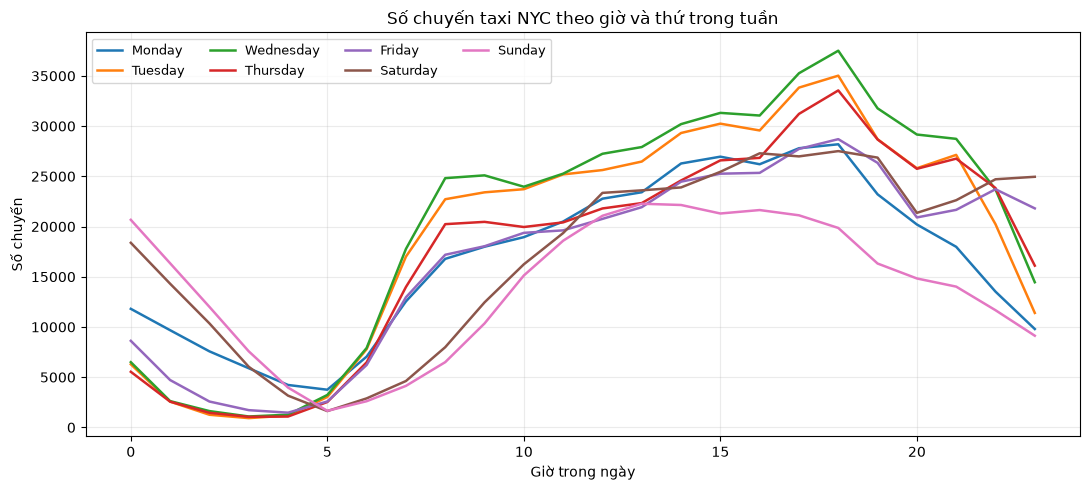

In [9]:
import matplotlib.pyplot as plt

thu_tu = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.pivot(index='gio', columns='thu', values='so_chuyen')[thu_tu]

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(ax=ax, linewidth=1.8)
ax.set_title('Số chuyến taxi NYC theo giờ và thứ trong tuần')
ax.set_xlabel('Giờ trong ngày'); ax.set_ylabel('Số chuyến')
ax.grid(alpha=0.25); ax.legend(title='', ncol=4, fontsize=9)
plt.tight_layout(); plt.show()


---
## Tự kiểm tra — Phase 0 coi như xong khi bạn làm được

**1. Vẽ lại sơ đồ 7 tầng lên giấy** (không nhìn notebook) và khoanh tròn hai tầng ta đã dựng.

**2. Trả lời không cần tra cứu:**
   - Vì sao tách storage khỏi compute lại quan trọng? (Gợi ý: nghĩ về chuyện tắt máy tính
     lúc đêm nhưng dữ liệu vẫn còn, và chuyện 5 nhóm cùng đọc một dữ liệu.)
   - Ta query file trong MinIO mà không import vào database nào. Vậy *cái gì* đang thiếu
     so với một database thật? Kể ra ít nhất ba thứ.

> Câu thứ hai chính là **danh sách việc phải làm của Phase 1 và Phase 2**.
> Nếu bạn tự nghĩ ra được "thiếu transaction", "thiếu schema bắt buộc", "thiếu chỉ mục",
> "thiếu chỗ ghi bảng nào tồn tại" — thì bạn đã tự phát minh lại Delta Lake và Unity Catalog.

**3. Thử phá cho hỏng:** xoá một file trong MinIO console (http://localhost:9001) trong khi
   đang query. Chuyện gì xảy ra? Ghi lại. Đây là bài học đầu tiên về việc vì sao
   "một đống file" chưa phải là "một cái bảng".

---
### Sang Phase 1
Khi xong, đánh dấu ✅ vào bảng theo dõi cuối `docs/roadmap.md`, rồi bảo tôi dựng Phase 1.
